The following notebook analyses bureau and bureau balance. The ultimate goal is to create a model that agglomerates the time series information of each individual into a more interpretable metric.

In [1]:
from helpers import preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from helpers.utils import plotting_helper
from helpers.utils.cleaner_helper import plot_categorical_dist
from helpers.custom_classifiers import MarkovPredictor
from sklearn.multioutput import MultiOutputClassifier
from lightgbm import LGBMClassifier
import importlib
from helpers.utils import model_helper
from helpers import bureau_helper

plotting_helper.set_plot_style()

# Bureau balance

In [2]:
balance = preprocessing.load_pkl_to_preprocessor("bureau_balance")
balance.convert_all("category")
balance_cols = balance.column_structure
print("columns of interest:", balance_cols)
balance.data.sort_values(
    ["SK_ID_BUREAU", "MONTHS_BALANCE"], ascending=(True, True), inplace=True
)

Loading tables: ['bureau_balance.csv']
loaded bureau_balance with shape (27299925, 3)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_BUREAU']
columns of interest: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']


bureau balance includes just three columns (from nb2):
* `SKI_ID_BUREAU` id of relevant application
* `MONTHS_BALANCE` time in months relative to application date.
    * `C`: Closed - Account was closed during (or by the end of) the month—no outstanding balance.
    * `X`: Unknown - Bureau has no reliable status for this account this month.
    * `0`: Current (no DPD) - The loan was active and never past due (0 days past due) at any point in the month.
    * `1`: DPD 0–30 - The single worst delinquency during the month was 1–30 days past due.
    * `2`: DPD 31–60...
    * `3`: DPD 61-90...
    * `4`: DPD 91-120...
    * `5`: DPD 120+ / Sold / Written‑off - The worst delinquency was over 120 days past due, or the account has been charged off, sold, or otherwise written off.


In [3]:
balance.data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27299925 entries, 26079849 to 23544003
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    int64   
 1   MONTHS_BALANCE  int64   
 2   STATUS          category
dtypes: category(1), int64(2)
memory usage: 650.9 MB


# Status prediction
Given that the history of people balances is known, being able to to define how the states evolve would provide valuable information for application evaluation purposes. Especially since that people with a history of delinquency would be more prone towards defaulting on a loan.

## Information depth
We first quantify how many data instances we have for each participant:

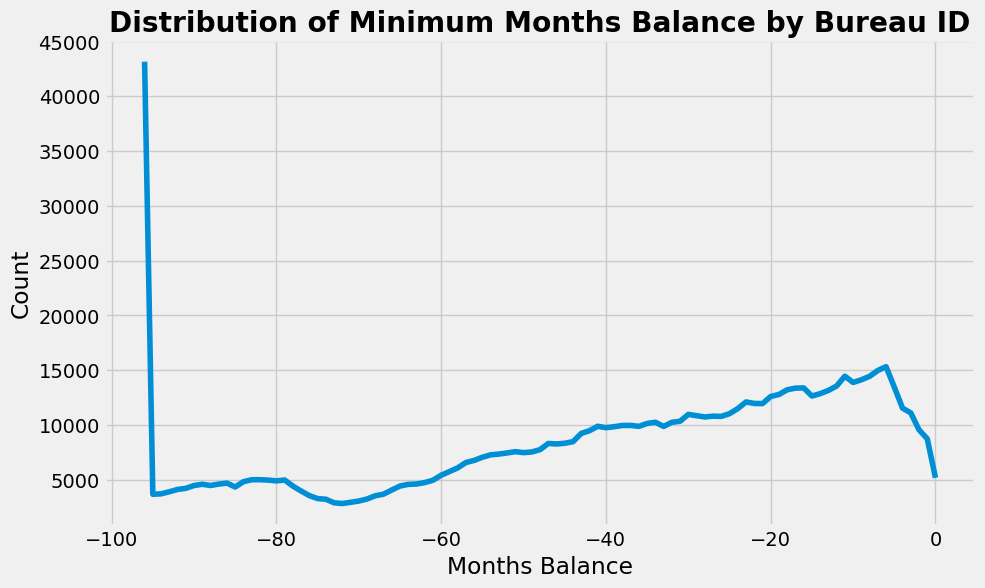

In [4]:
time_dist = (
    balance.data.groupby("SK_ID_BUREAU")["MONTHS_BALANCE"]
    .min()
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10, 6))
sns.lineplot(x=time_dist.index, y=time_dist.values)
plt.xlabel("Months Balance")
plt.ylabel("Count")
plt.title("Distribution of Minimum Months Balance by Bureau ID")
plt.show()

* Majority of applicant have history of spanning 100 months back.
    * Information older than 100 months (8.3 years) is not stored.
* Significant portion of individuals have less than 100 months of balance history, implying that the information was not collected about them.

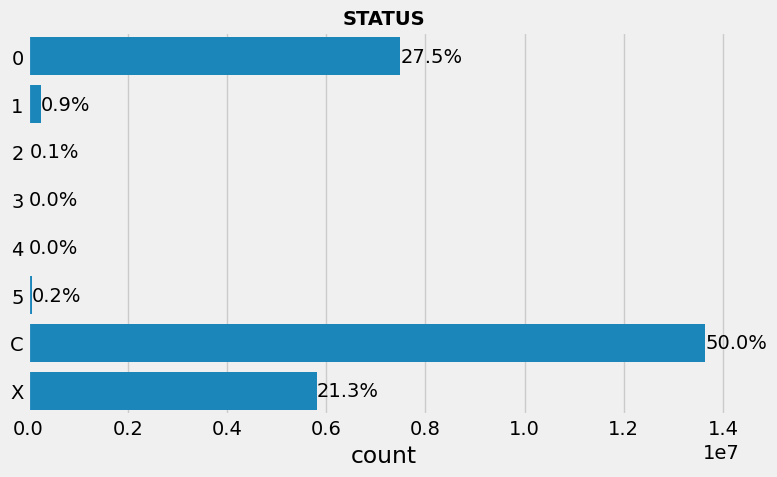

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

In [5]:
plot_categorical_dist(balance.data, "STATUS")

* Majority of active loans were never past due.
* Half of data are closed loans.
* 21% of states are unknown and thus not informative.

# Transition of states
For a broad picture, we model the data as a **discrete-state discrete-time Markov process** with the following caveat:
* Individual application and time duration are ignored.
    - transition 1 and 99 months ago are considered equivalent.
    - Transitions that occurred in different individuals are identical to those that occurred within an individual.

Consequently, we consider all transitions of **X(id, t) -> X(id, t+1)**, where X is state (`STATUS`) id is `SK_ID_CURR` and t is `MONTHS_BALANCE`, as equivalent.

We thus construct a transition matrix from observed events, where: i (row) indicates the ingoing state and j (column) indicates the outgoing state.

We then count the observed transitions as:

In [6]:
transition_matrix = pd.DataFrame(
    0,
    index=sorted(balance.data["STATUS"].unique()),
    columns=sorted(balance.data["STATUS"].unique()),
)
df_sorted = balance.data.copy().sort_values(["SK_ID_BUREAU", "MONTHS_BALANCE"])
df_sorted["next_status"] = df_sorted.groupby("SK_ID_BUREAU")["STATUS"].shift(-1)
transitions = df_sorted.dropna(subset=["next_status"])
df_sorted.head(100)

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS,next_status
26079849,5001709,-96,X,X
26079848,5001709,-95,X,X
26079847,5001709,-94,X,X
26079846,5001709,-93,X,X
26079845,5001709,-92,X,X
...,...,...,...,...
26079754,5001709,-1,C,C
26079753,5001709,0,C,NaN
2846398,5001710,-82,X,X
2846397,5001710,-81,X,X


In [7]:
transition_counts = transitions.groupby(["STATUS", "next_status"], observed=True).size()

for (current, next_state), count in transition_counts.items():
    transition_matrix.loc[next_state, current] += count

transition_matrix

,0,1,2,3,4,5,C,X
0,6299377,113244,5779,1090,402,1131,1,631094
1,145151,81874,3378,504,167,193,50,10182
2,3549,13845,4209,457,109,148,0,1001
3,225,229,6980,1019,138,71,0,224
4,38,2,147,4769,466,110,0,250
5,822,56,18,119,3821,55805,0,1609
C,356053,19273,1653,646,431,1880,13197338,51746
X,536964,8056,969,234,250,1810,1,4911373


Following observations can be made:
* Majority of closed accounts remain closed.
    * Ignoring a few outliers, closed account can be considered a transition state.
* Majority of active balances are paid on time.
* Majority of severe delinquencies (>120) remain in such state. 
* **Information is often lost. i.e. the state becomes unknown**

We then finish deriving the matrix:

Text(34.58333333333333, 0.5, 'Next State')

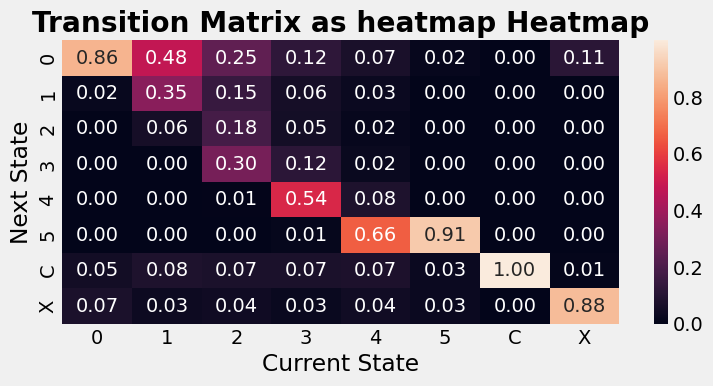

In [8]:
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=0), axis=1)
transition_matrix.round(2)
plt.figure(figsize=(8, 3.5))
sns.heatmap(transition_matrix, annot=True, fmt=".2f")
plt.title("Transition Matrix as heatmap Heatmap")
plt.xlabel("Current State")
plt.ylabel("Next State")

We thus can derive such rules of thumb:
* Closed account is an absorbing state.
* Unknown balances remain unknown until an individual takes out a loan. i.e. the balance starts as paid.
* Delinquencies can only progress one at a time (effect of 30 days time scale).
* People tend to decrease delinquency severity
* Accounts at stage 5 (120+ / Sold / Written‑off) tend to stabilise.
    * The state is only realistic exited by paying off the debt or closing the account.
    * This is a huge oversight on status side, since it 3 states are agglomerated.

Consequently, if we treat prediction as a progression of probability distribution:
* All accounts will be eventually closed.
* Unknown accounts will progress into state 0.
* Balances of state 4,5 will tend to state 5 (before being closed).
* Balances of state 0, 1, 2, 3 will tend to lower states (before eventually being closed).

Thus **only individuals in states 4, 5 are in grounds for concerns**.



#### Simplified State Diagram

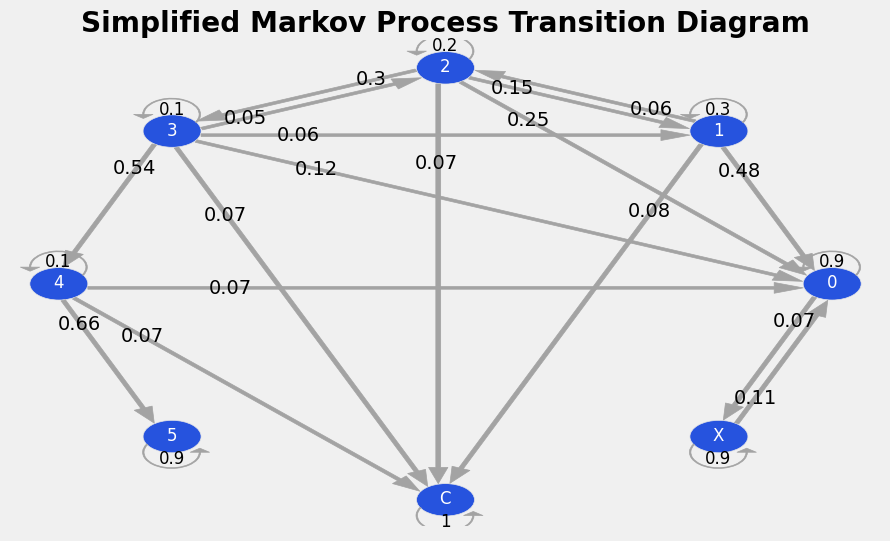

In [9]:
from helpers.utils.markov_chain import markovchain

importlib.reload(markovchain)
drawn_matrix = transition_matrix * (transition_matrix > 0.05).astype(int)
mc = markovchain.MarkovChain(
    drawn_matrix,
    transition_matrix.index,
    transparency_func=lambda x: 1,
    arrow_head_width=0.4,
)
mc.figsize = (10, 6)
mc.draw()
plt.title("Simplified Markov Process Transition Diagram");

## Markov process predictive power.
We now evaluate the predictive power of the Markov process by predicting the t=0 state using t=1 state in our dataset. 

In [10]:
df = balance.data.copy()

states_df = (
    df[df["MONTHS_BALANCE"].isin([-1, 0])]
    .pivot_table(
        index="SK_ID_BUREAU", columns="MONTHS_BALANCE", values="STATUS", aggfunc="first"
    )
    .rename(columns={-1: "penul", 0: "state"})
    .dropna()
)

states_df.head()

MONTHS_BALANCE,penul,state
SK_ID_BUREAU,,
5001709,C,C
5001710,C,C
5001711,0,X
5001712,C,C
5001713,X,X


We then use a custom class, which simplifies handling predictions from a transition matrix as our classifier.

F1 Score: 0.5731636803001697


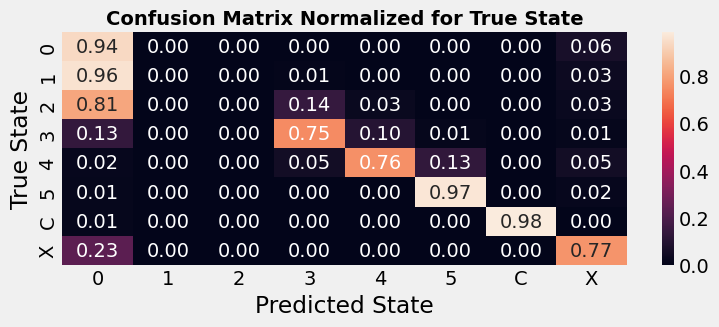

In [11]:
markov_predictor = MarkovPredictor(transition_matrix)

y_pred = markov_predictor.predict(states_df["penul"])
y_bin = markov_predictor.binarice_true_labels(states_df["state"])

plt.figure(figsize=(8, 3.5))
model_helper.evaluate_multiclass_model(y_bin, y_pred, columns=markov_predictor.classes_)

* States 1 and 2 were never predicted.
* State 0 was correctly assigned 75% of the time
* State 5 was often correctly assigned.
* State 3 was usually misaligned.
* ROC AUC 0.89 is affected by highly imbalanced data.

#### Simplified state diagram

# 

## ML predictor:
Main advantage of previously derived transition matrix is expandability. We try and construct a more useful and accurate ml model from provided information.

The goal is to try and predict 3 upcoming month states based on 10 previous months.

## Data aggregation
The data is then aggregated into columns of 13 months (10 predictors +3 response variables):

We first identify columns that will work well to confirm our results. We want a balance that is both short and has multiple diverse statuses to allow easy comparison.

In [12]:
bureau_counts = df.groupby("SK_ID_BUREAU").size()

short_bureaus = bureau_counts[bureau_counts < 20].index

status_diversity = (
    df[df["SK_ID_BUREAU"].isin(short_bureaus)]
    .groupby("SK_ID_BUREAU")["STATUS"]
    .nunique()
    .sort_values(ascending=False)
)

print(status_diversity.head(3))

SK_ID_BUREAU
5416811    8
5706931    8
5452673    8
Name: STATUS, dtype: int64


We thus construct the testing frame.

In [13]:
importlib.reload(bureau_helper)
train_sequences = bureau_helper.encode_agg_bureau_balance(
    df[df["SK_ID_BUREAU"] == 5706931], lookback=10, forecast=3, include_end_month=True
)

display(train_sequences[train_sequences["SK_ID_BUREAU"] == 5706931])


display(df[df["SK_ID_BUREAU"] == 5706931])

,MONTHS_BALANCE,SK_ID_BUREAU,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,first_pred_month,t_0,t_1,t_2
0,-17,5706931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17,X,0,0
1,-16,5706931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,-16,0,0,0
2,-15,5706931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,0,-15,0,0,0
3,-14,5706931,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,0,0,-14,0,0,1
4,-13,5706931,NaN,NaN,NaN,NaN,NaN,NaN,X,0,0,0,-13,0,1,2
5,-12,5706931,NaN,NaN,NaN,NaN,NaN,X,0,0,0,0,-12,1,2,3
6,-11,5706931,NaN,NaN,NaN,NaN,X,0,0,0,0,1,-11,2,3,4
7,-10,5706931,NaN,NaN,NaN,X,0,0,0,0,1,2,-10,3,4,5
8,-9,5706931,NaN,NaN,X,0,0,0,0,1,2,3,-9,4,5,5
9,-8,5706931,NaN,X,0,0,0,0,1,2,3,4,-8,5,5,5


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
5232358,5706931,-17,X
5232357,5706931,-16,0
5232356,5706931,-15,0
5232355,5706931,-14,0
5232354,5706931,-13,0
5232353,5706931,-12,1
5232352,5706931,-11,2
5232351,5706931,-10,3
5232350,5706931,-9,4
5232349,5706931,-8,5


We thus see that our modified frame was constructed successfully.

#### Train test split

To avoid data leakage, we will separate our 3 most recent months as the test set. Remaining months will be used for the train set. Since our data is produced by shifting, the train dataset size is highly expanded.

In [14]:
train_data = balance.data[balance.data["MONTHS_BALANCE"] <= -3]
X_train, y_train = bureau_helper.encode_agg_bureau_balance(
    train_data, lookback=10, forecast=3, include_end_month=False, X_y_split=True
)

print("X_train shape:", X_train.shape)

print("y_train  shape:", y_train.shape)

test_data = balance.data[balance.data["MONTHS_BALANCE"] > (-3 - 10)]
X_test, y_test = bureau_helper.encode_agg_bureau_balance(
    test_data,
    lookback=10,
    forecast=3,
    include_end_month=False,
    X_y_split=True,
    test=True,
)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (23871307, 10)
y_train  shape: (23871307, 3)
X_test shape: (597099, 10)
y_test shape: (597099, 3)


#### Multioutput classifier

In [15]:
model = MultiOutputClassifier(
    LGBMClassifier(
        verbose=-1,
        random_state=3,
        is_unbalance="True",
        objective="multiclass",
        n_jobs=-1,
    )
)

model = model_helper.save_or_load_model(
    model, X_train, y_train, "bureau_balance_multioutput.pkl"
)
model

Model loaded from models\bureau_balance_multioutput.jbl


,estimator,"LGBMClassifie...3, verbose=-1)"
,n_jobs,None
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0


Training on CPU took 23 minutes.

F1 Score: 0.6373903799586984


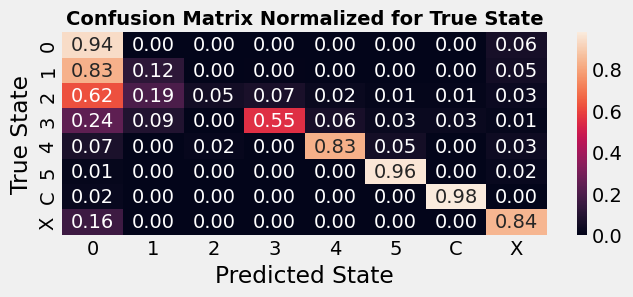

F1 Score: 0.5248642936141266


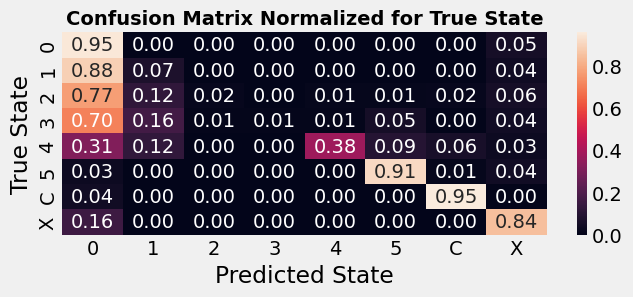

F1 Score: 0.43644870085992604


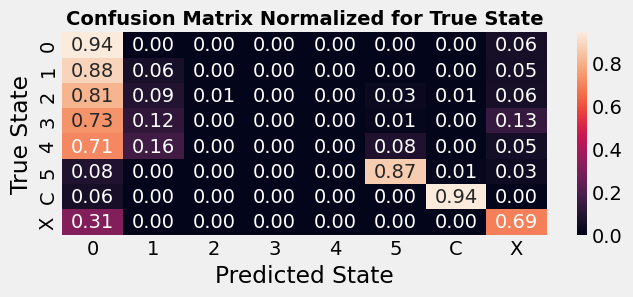

In [16]:
y_test_pred = model.predict(X_test)
pred_df = pd.DataFrame(y_test_pred, columns=[f"t_{i}" for i in range(3)])
for col in y_test.columns:
    plt.figure(figsize=(7, 3.2))
    model_helper.evaluate_multiclass_model(y_test[col], pred_df[col], model.classes_[0])
    plt.show()

* Model f1_macro improved to (0.64 vs 0.57) for first predicted state
    * Most states are assigned with high accuracy, except for 2 and 3.
    * Falsely assigned states are usually assigned to 0 (active account that pays on time)
* Second unknown state prediction is comparable to that of first state for markov process (0.53 vs 0.57)
* Predictions become increasingly poor afterwards.